In [ ]:
# Plot the points from a saved result files.

from funman.server.query import FunmanResults
import json
import glob
import os

from funman.server.query import FunmanResultsTiming
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt


# %load_ext autoreload
# %autoreload 2

# Get timing results
out_files = glob.glob("out/*.json")
all_results = {}
for out_file in out_files:
    with open(out_file, "r") as f:
        results = FunmanResults.model_validate(json.load(f))
        # results.plot(variables=["I"], label_marker={"true":",", "false": ","})
        all_results[out_file] = results.timing



# Construct Dataframe

def get_meta_from_name(filename):
    print(f"Getting meta from {filename}")
    rootname, ext = os.path.splitext(os.path.basename(filename))
    if "_" in rootname:
        [model, size, phase] = rootname.split("_")
    else:
        model = size = phase = None
    return {"name" : rootname,
        "model": model,
        "size": size,
        "phase": phase
        }

def get_timing(results_timing: FunmanResultsTiming):
    timing = results_timing.model_dump()
    return timing

data = []
for k, v in all_results.items():
    meta = get_meta_from_name(k)
    timing = get_timing(v)
    data.append({**meta, **timing})
df = pd.DataFrame(data)
df = df[[c for c in df.columns if c!= "progress_timeseries"]].join(df.progress_timeseries.explode())
df["timepoint"] = df.progress_timeseries.apply(lambda x: x[0])
df["coverage"] = df.progress_timeseries.apply(lambda x: x[1])
df = df.sort_values(by=["size", "phase", "coverage"])
df["elapsed"] = df.timepoint - df.start_time
df["seconds"] = df.elapsed.apply(timedelta.total_seconds)

# Interpret size of instance relative to smallest instance

def remove_trailing_zeros(s):
    if '.' in s:
        s = s.rstrip('0').rstrip('.')
    return s

scales = [-0.99, -0.75, -0.5, -0.25, -0.1, 0, 0.1, 0.25, 0.5, 0.75, 0.99]
rescales = [(1.0+s)/(1.0+scales[0]) for s in scales]
rescale= {remove_trailing_zeros(f"{s:.2f}"):remove_trailing_zeros(f"{r:.2f}") for s,r in zip(scales, rescales)}

df['resize'] = df['size'].apply(lambda x: rescale[x])

{'out/sir_-0.1_phase2.json': FunmanResultsTiming(start_time=datetime.datetime(2025, 4, 25, 19, 10, 52, 797444), end_time=datetime.datetime(2025, 4, 25, 19, 11, 30, 507248), total_time=datetime.timedelta(seconds=37, microseconds=709804), solver_time=None, encoding_time=None, progress_timeseries=[(datetime.datetime(2025, 4, 25, 19, 10, 57, 930352), 0.09090909090909101), (datetime.datetime(2025, 4, 25, 19, 10, 58, 954898), 0.45454545454545503), (datetime.datetime(2025, 4, 25, 19, 11, 0, 128779), 0.45454545454545503), (datetime.datetime(2025, 4, 25, 19, 11, 1, 156590), 0.46569613964702405), (datetime.datetime(2025, 4, 25, 19, 11, 2, 215312), 0.796510904156975), (datetime.datetime(2025, 4, 25, 19, 11, 3, 293450), 0.797248416444958), (datetime.datetime(2025, 4, 25, 19, 11, 4, 321523), 0.7978453373484711), (datetime.datetime(2025, 4, 25, 19, 11, 5, 366005), 0.8036525250873601), (datetime.datetime(2025, 4, 25, 19, 11, 6, 438510), 0.804041578466078), (datetime.datetime(2025, 4, 25, 19, 11, 7, 5

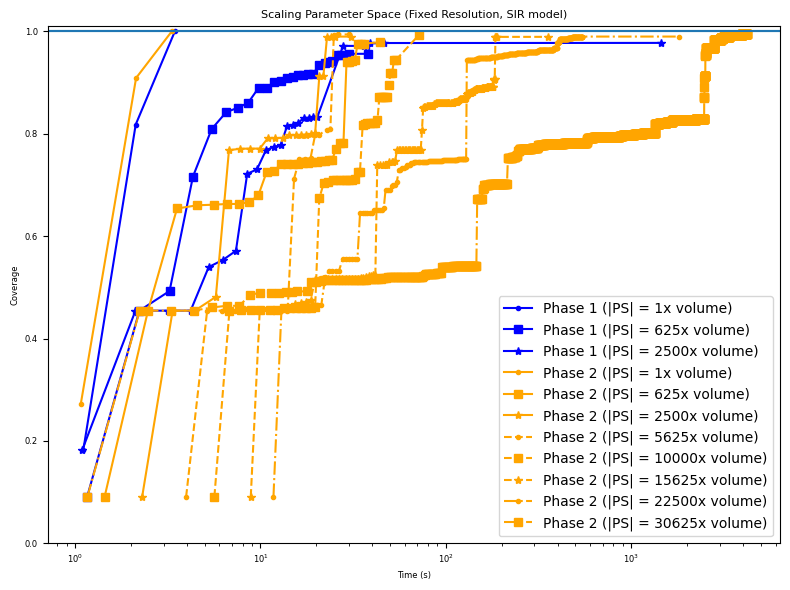

In [ ]:
# Plot the results 

scales_to_plot = ["1", "25", "50", "75", "100", "125", "150", "175"]
styles = {"1": ("-", "."), "25": ("-", "s"), "50": ("-", "*"), "75": ("--", "."), "100": ("--", "s"), "125": ("--", "*"), "150": ("-.", "."), "175": ("-.", "s")} 
fig, axs = plt.subplots(
    1, #len(scales_to_plot),
    1,sharex=True, figsize=(8,6))
color = {"baseline": "blue", "phase2": "orange"}
renamed={"phase2": "Phase 2", "baseline": "Phase 1"}
rescales_to_plot = [ remove_trailing_zeros(f"{r:.2f}") for r in rescales if remove_trailing_zeros(f"{r:.2f}") in scales_to_plot]
for phase in ["baseline", "phase2"]:
    for i, scale in enumerate(rescales_to_plot):
    # for i, ax in enumerate(axs):
        ax  = axs # [i]
        scale_df = df.loc[df.resize == scale]
        plot_df = scale_df.loc[(scale_df.phase == phase)][["seconds", "coverage"]]

        if len(plot_df) > 0:
            ax.plot(plot_df['seconds'], plot_df['coverage'], label=f"{renamed[phase]} (|PS| = {float(scale)*float(scale):.0f}x volume)", linestyle=styles[scale][0], marker=styles[scale][1], color=color[phase])
    ax.set_title(f"Scaling Parameter Space (Fixed Resolution, SIR model)")
    ax.set_xscale("log")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Coverage")
    plt.axhline(y=1)
    ax.legend()
    ax.set_ylim(0, 1.01)
    # break
plt.tight_layout()
plt.show()


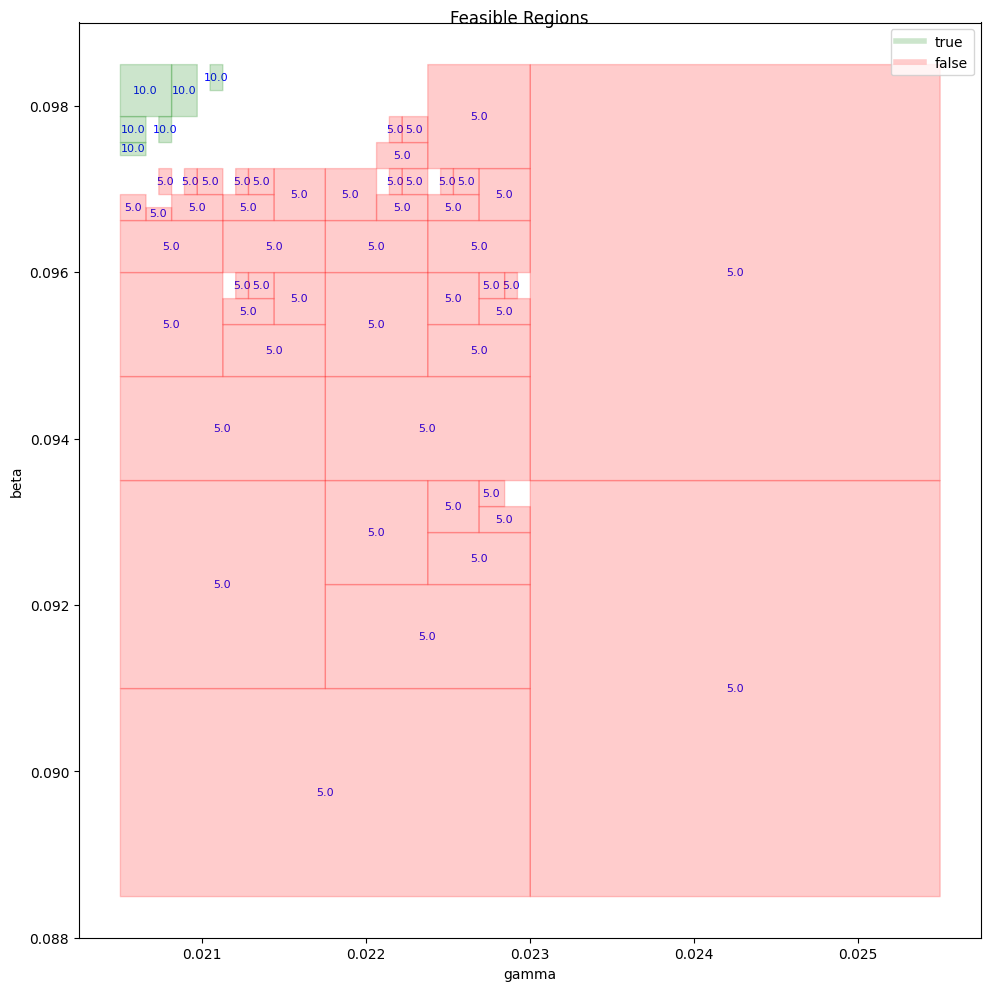

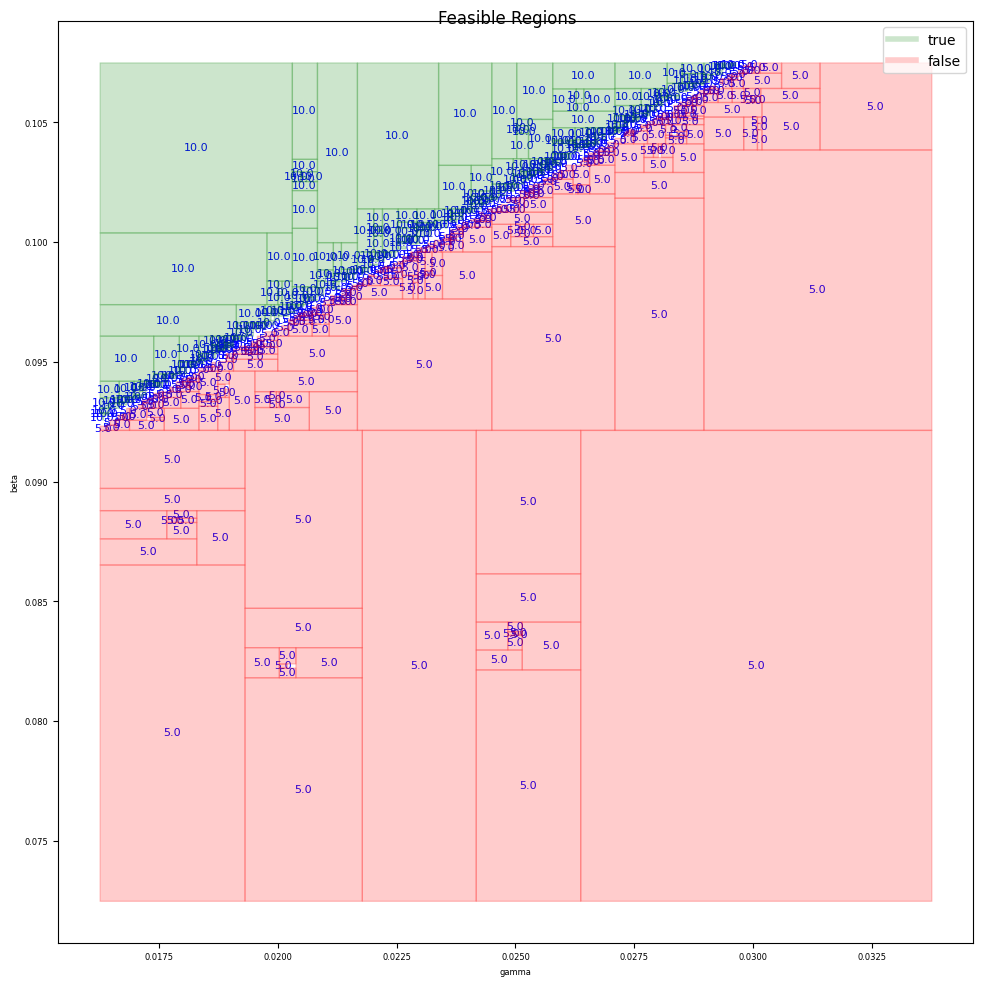

In [3]:
# Plot the parameter spaces for each result

from funman_demo.parameter_space_plotter import ParameterSpacePlotter
from matplotlib import pyplot as plt
to_render = ["out/sir_-0.5_baseline.json", "out/sir_0.75_phase2.json"]
for out_file in to_render:
    with open(out_file, "r") as f:
        results = FunmanResults.model_validate(json.load(f))
        boxes = results.parameter_space.last_boxes(steps=[results.parameter_space.last_step()])
        psp = ParameterSpacePlotter(
                results.parameter_space, boxes=boxes, plot_points=False, parameters=["beta", "gamma"], figsize=(10,10)
            )
        psp.plot(show=False)
        plt.savefig(f"{out_file}.png")
# psp.axs